<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/rnn/rnn-gru-agnews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [ ]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [ ]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.10.0+cu128



---
# Gated Recurrent Unit (GRU) Classifier on AG News

The network in this notebook is an implementation of a **Gated Recurrent Unit (GRU)** network **[1]** on AG news dataset **[8, 9]**. The model is a **Single-Layer GRU** implemented from scratch. It utilizes a streamlined gating structure to maintain long-term dependencies without the complexity of a separate cell state, making it a robust and efficient alternative to the LSTM.
<br><br><br>

**Network Architecture:**

The GRU was introduced as a simpler, more computationally efficient evolution of the LSTM **[1]**. While the LSTM uses three gates and a dual-state system (Hidden + Cell), the GRU simplifies this into two gates—**Update** and **Reset**—and a single **Hidden State ($h_t$)**. The GRU simplifies the LSTM by merging the cell and hidden states and reducing the gate count to two.



![RNN architecture](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-SimpleRNN.png)

**The repeating module in a standard RNN contains a single layer.** ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/), **[6]**)

<br><br><br>

![LSTM architecture](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

**The repeating module in an LSTM contains four interacting layers.** ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/), **[6]**)

<br><br><br>

![GRU](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-var-GRU.png)

**GRU Unit Cell** ([Source](https://colah.github.io/posts/2015-08-Understanding-LSTMs/), **[6]**)

<br><br><br>

---

### **Key Concepts of the `GRU` Architecture:**

1. **Unified Hidden State ($h_t$):** Unlike the LSTM, the GRU does not have a separate "cell state." Instead, the hidden state acts as both the working memory and the long-term memory track. This reduces the memory footprint and simplifies the implementation.
2. **Gating Mechanisms:** GRUs use two specialized gates to control the flow of information:
* **Update Gate ($z_t$):** Determines how much of the previous hidden state should be retained and how much of the new candidate state should be mixed in. It effectively combines the "Forget" and "Input" functions of an LSTM.
* **Reset Gate ($r_t$):** Controls how much of the past information to "forget" before calculating the new candidate hidden state.


3. **Linear Interpolation:** The final hidden state is a weighted average (interpolation) between the previous state and the new candidate. This allows the gradient to persist through many time steps, effectively solving the vanishing gradient problem.
<br><br><br>

---

### **Improvements of `GRU` over `LSTM` and Simple `RNN`:**

1. **Efficiency and Speed:** With only two gates instead of three (and fewer matrix multiplications), the GRU has approximately **33% fewer parameters** than an LSTM. This makes it faster to train and less prone to overfitting on smaller datasets.
2. **Stable Gradients:** Similar to the LSTM, the GRU uses additive updates. This prevents the gradients from shrinking exponentially, allowing the model to learn context across long news articles.
3. **Performance Parity:** On many NLP tasks, such as topic classification (AG News) or sentiment analysis (IMDB), the GRU performs as well as, or sometimes better than, the LSTM while being more computationally "robust" for resource-constrained environments.
<br><br><br>

---

### **Quick Comparison Table: RNN vs. LSTM vs. GRU**

| Feature | Simple RNN | LSTM | Gated Recurrent Unit (GRU) |
| --- | --- | --- | --- |
| **State Count** | Single ($h_t$) | **Dual ($h_t, c_t$)** | **Single ($h_t$)** |
| **Gate Count** | 0 | 3 (Forget, Input, Output) | **2 (Update, Reset)** |
| **Complexity** | Low | High | **Medium (Efficient)** |
| **Memory Usage** | Lowest | Highest | **Moderate (Optimized)** |
| **Gradient Flow** | Multiplicative | **Additive** | **Additive (Interpolation)** |
| **Implementation** | Simple | Complex | **Streamlined** |
| **Parameter Count** | $W$ | $\approx 4 \times W$ | **$\approx 3 \times W$** |



<br><br><br>

**REFERENCES:**

1. Cho, Kyunghyun, et al. ["Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation."](https://arxiv.org/abs/1406.1078) *arXiv*, 2014. (Original GRU paper)
2. Hochreiter, Sepp, and Jürgen Schmidhuber. ["Long Short-Term Memory."](https://www.bioinf.jku.at/publications/older/2604.pdf) 1997.
3. Elman, Jeffrey L. ["Finding Structure in Time."](https://onlinelibrary.wiley.com/doi/abs/10.1207/s15516709cog1402_1) 1990.
4. PyTorch. ["Recurrent Layers: nn.GRU."](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html) 2026.
5. Zhang, Aston, et al. ["Gated Recurrent Units (Chapter 10.2)."](https://d2l.ai/chapter_recurrent-modern/gru.html) *Dive into Deep Learning*. 2023.
6. Olah, Christopher. ["Understanding LSTM Networks."](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) *colah's blog*, 2015.
7. Karpathy, Andrej. ["The Unreasonable Effectiveness of Recurrent Neural Networks."](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) *Andrej Karpathy blog*, 2015.
8. Zhang, Xiang, Junbo Zhao, and Yann LeCun. ["Character-level Convolutional Networks for Text Classification."](https://arxiv.org/abs/1509.01626) *Advances in Neural Information Processing Systems (NeurIPS)*, 2015.
9. Gulli, Antonio. ["AG's Corpus of News Articles."](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html) 2004.
10. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI


---

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [ ]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [ ]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
NUM_CLASSES = 1

VOCABULARY_SIZE = 20000

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
# OUTPUT_DIM = 1

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [ ]:
# 1. Load Dataset (IMDB)
raw_datasets = load_dataset("ag_news")


# 2. Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")

# 3. Custom Dataset Class
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split):
        self.data = dataset_split

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Return raw text and label. Let collate_fn handle the rest.
        item = self.data[idx]
        return item['text'], item['label']

# 4. Robust Text Pipeline
def text_pipeline(text, max_len=128):
    tokens = tokenizer(text)
    # Use .get(t, 1) because 1 is your <UNK> index
    return [vocab.get(t, 1) for t in tokens][:max_len]

# 5. Robust Collate Batch
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []

    for _text, _label in batch:
        # 1. Labels: Use LONG for AG News (Multi-class)
        label_list.append(_label)

        # 2. Numericalize and Truncate
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))

    # 3. Padding logic
    # We use <PAD> index 0. We use vocab.get just in case names change.
    pad_idx = vocab.get('<PAD>', 0)

    # This dynamically pads to the longest sequence in THIS batch (more efficient)
    text_list_padded = pad_sequence(text_list, batch_first=True, padding_value=pad_idx)
    label_tensor = torch.tensor(label_list, dtype=torch.long)
    length_tensor = torch.tensor(lengths, dtype=torch.int64)

    return text_list_padded.to(DEVICE), label_tensor.to(DEVICE), length_tensor.to(DEVICE)

# 6. Initialize DataLoaders
train_ds = TextDataset(ds_splits['train'])
val_ds   = TextDataset(ds_splits['validation'])
test_ds  = TextDataset(ds_splits['test'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Vocab size: 20002


---
# 2. Model Creation 

---


In [ ]:
class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        # We need weights for 3 operations:
        # Update gate (z), Reset gate (r), and Candidate hidden state (h_tilde)
        self.gate_weights = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.candidate_weights = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):
        # x: [batch, input_size]
        # h_prev: [batch, hidden_size]

        # 1. Calculate Update (z) and Reset (r) gates
        combined = torch.cat((x, h_prev), dim=1)
        gates = torch.sigmoid(self.gate_weights(combined))
        z_gate, r_gate = gates.chunk(2, dim=1)

        # 2. Calculate Candidate Hidden State (h_tilde)
        # We use the Reset gate to "mask" the previous hidden state
        combined_candidate = torch.cat((x, r_gate * h_prev), dim=1)
        h_tilde = torch.tanh(self.candidate_weights(combined_candidate))

        # 3. Final Hidden State update
        # This is a linear interpolation between past and candidate
        h_curr = (1 - z_gate) * h_prev + z_gate * h_tilde

        return h_curr

In [ ]:
class GRUFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.cell = GRUCellFromScratch(embed_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, lengths):
        batch_size, seq_len = x.shape
        x = self.embedding(x) # [batch, seq, embed]

        # Initialize h_0 as zeros
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # To handle padding robustly, we store ALL hidden states
        all_h = []

        for t in range(seq_len):
            h = self.cell(x[:, t, :], h)
            all_h.append(h.unsqueeze(1)) # [Batch, 1, Hidden]

        # Stack them: [Batch, Seq_Len, Hidden]
        all_h = torch.cat(all_h, dim=1)

        # ROBUST TRICK: Select the hidden state at the ACTUAL end of each sentence
        # We subtract 1 because lengths are 1-indexed, but indices are 0-indexed
        idx = (lengths - 1).view(-1, 1, 1).expand(batch_size, 1, self.hidden_size)  # [batch, 1, hidden]
        last_h = all_h.gather(1, idx).squeeze(1)  # [batch, hidden]

        return self.fc(last_h)

In [ ]:
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex[0])) for ex in dataset]
    p_length = np.percentile(lengths, p)

    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))

    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)

    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")

    return final_len

# Usage
_MAX_LEN = get_robust_maxlen(train_ds, tokenizer, p=95)

95th Percentile: 58.00
Nearest Power of 2: 64
Final Robust MAX_LEN: 64


In [ ]:
VOCAB_SIZE = len(vocab)
MAX_LEN = 64

In [ ]:
# --- Configuration Switch ---
DATASET_NAME = "ag-news"

if DATASET_NAME == "IMDB":
    IS_BINARY = True
    NUM_CLASSES = 1
    # criterion = nn.BCEWithLogitsLoss()
else:
    IS_BINARY = False
    NUM_CLASSES = 4 # AG News has 4 classes
    # criterion = nn.CrossEntropyLoss()

In [ ]:
set_all_seeds(RANDOM_SEED)
model = GRUFromScratch(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_DIM,
    output_size=NUM_CLASSES
).to(DEVICE)

summary(model,
        input_data=(torch.zeros((BATCH_SIZE, MAX_LEN), dtype=torch.long).to(DEVICE),
                    torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * MAX_LEN),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
GRUFromScratch                           [128, 64]                 [128, 4]                  --                        --
├─Embedding: 1-1                         [128, 64]                 [128, 64, 128]            2,560,256                 327,712,768
├─GRUCellFromScratch: 1-2                [128, 128]                [128, 256]                --                        --
│    └─Linear: 2-1                       [128, 384]                [128, 512]                197,120                   25,231,360
│    └─Linear: 2-2                       [128, 384]                [128, 256]                98,560                    12,615,680
├─GRUCellFromScratch: 1-3                [128, 128]                [128, 256]                (recursive)               --
│    └─Linear: 2-3                       [128, 384]                [128, 512]                (recursive)          

---
# 3. Model Training, Testing & Evaluation

---

In [ ]:
def calculate_accuracy(loader, model, device, is_binary=True):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels, lengths in loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            logits = model(inputs, lengths)

            if is_binary:
                predicted = (torch.sigmoid(logits.view(-1)) > 0.5).long()
            else:
                _, predicted = torch.max(logits.data, 1)

            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()

    return 100 * correct / total

In [ ]:
IS_BINARY, NUM_CLASSES

(False, 4)

In [ ]:
# 1. Update Optimizer and Scheduler
# Binary uses BCEWithLogitsLoss; Multi-class uses CrossEntropy
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Robust Scheduler: Cosine Annealing
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {DEVICE}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    # 1. Training Phase
    for i, (inputs, labels, lengths) in enumerate(train_loader):
        inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

        optimizer.zero_grad()

        # Forward pass (passing lengths for masking logic)
        logits = model(inputs, lengths)

        if IS_BINARY:
            loss = criterion(logits.squeeze(), labels.float())
        else:
            loss = criterion(logits, labels.long())

        loss.backward()

        # --- ROBUST RNN FIX: Gradient Clipping ---
        # Prevents gradients from "exploding" during the backprop through time (BPTT)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # 2. Metrics Calculation
    # Note: Using the updated calculate_accuracy that handles (inputs, lengths)
    train_loss = running_loss / len(train_ds)
    train_acc = calculate_accuracy(train_loader, model, DEVICE, is_binary=IS_BINARY)

    # 3. Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

            logits = model(inputs, lengths)

            if IS_BINARY:
                loss = criterion(logits.squeeze(), labels.float())
            else:
                loss = criterion(logits, labels.long())

            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_ds)
    val_acc = calculate_accuracy(val_loader, model, DEVICE, is_binary=IS_BINARY)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 4. Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Loss (train/val): {train_loss:.4f} / {val_loss:.4f} | '
          f'Acc (train/val): {train_acc:.2f}% / {val_acc:.2f}% | '
          f'LR: {current_lr:.6f}')

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

Starting training on cuda...
Epoch 1/20 | Loss (train/val): 0.5125 / 0.3253 | Acc (train/val): 91.06% / 89.14% | LR: 0.000994
Epoch 2/20 | Loss (train/val): 0.2579 / 0.2749 | Acc (train/val): 94.10% / 90.83% | LR: 0.000976
Epoch 3/20 | Loss (train/val): 0.1865 / 0.2701 | Acc (train/val): 95.93% / 91.15% | LR: 0.000946
Epoch 4/20 | Loss (train/val): 0.1292 / 0.2903 | Acc (train/val): 97.23% / 90.83% | LR: 0.000905
Epoch 5/20 | Loss (train/val): 0.0855 / 0.3198 | Acc (train/val): 98.69% / 90.79% | LR: 0.000854
Epoch 6/20 | Loss (train/val): 0.0521 / 0.3736 | Acc (train/val): 99.27% / 90.92% | LR: 0.000794
Epoch 7/20 | Loss (train/val): 0.0316 / 0.4569 | Acc (train/val): 99.25% / 90.74% | LR: 0.000727
Epoch 8/20 | Loss (train/val): 0.0211 / 0.4978 | Acc (train/val): 99.62% / 90.46% | LR: 0.000655
Epoch 9/20 | Loss (train/val): 0.0146 / 0.5152 | Acc (train/val): 99.78% / 90.48% | LR: 0.000578
Epoch 10/20 | Loss (train/val): 0.0100 / 0.5379 | Acc (train/val): 99.86% / 90.78% | LR: 0.000500


In [ ]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader, model, DEVICE, is_binary=IS_BINARY)
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')


Final Test Accuracy: 90.86%


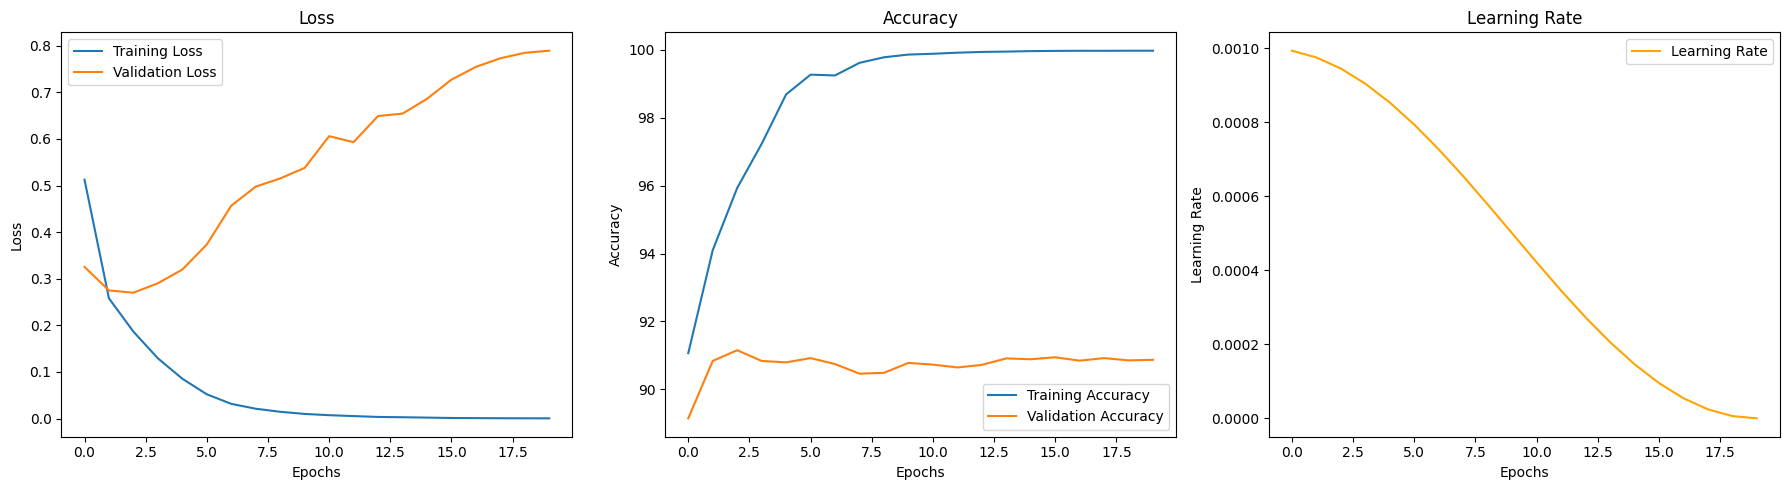

In [ ]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    # Plot 3: Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], label='Learning Rate', color='orange')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_history(history)

---
## 4. Model Inference and Sentiment Prediction

---

In [ ]:
# 1. Define the Human Labels
ag_news_labels = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

# 2. Re-use your Training Tokenizer
# This ensures "Don't" becomes ["don", "t"] consistently in both phases
tokenizer = lambda text: re.findall(r'\w+', text.lower())


# Adapted the below code from:
# https://github.com/bentrevett/pytorch-sentiment-analysis/blob/experimental/2%20-%20Upgraded%20Sentiment%20Analysis.ipynb
def predict_topic(model, sentence):
    model.eval()

    # Step A: Tokenize exactly like training
    tokens = tokenizer(sentence)

    # Step B: Numericalize using the <UNK> index (1)
    indexed = [vocab.get(t, 1) for t in tokens]

    # Step C: Prepare Tensors [Batch, Seq_Len]
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)

    with torch.no_grad():
        # Step D: Forward Pass
        logits = model(tensor, length)

        # Step E: Get the highest score
        # Using softmax to see the confidence %
        probs = torch.softmax(logits, dim=1)
        prediction_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][prediction_idx].item()

    return ag_news_labels[prediction_idx], confidence

# --- Test ----------------------------------------
headline = "The Olympic games were postponed due to global health concerns."
topic, score = predict_topic(model, headline)
print(f"Result: {topic} ({score:.2%})")

Result: Sports (97.99%)


In [ ]:
# Create a list of test cases
ag_news_tests = [
    "The Federal Reserve is expected to keep interest rates steady as inflation cools.", # Business
    "The star striker scored a hat-trick in the final minutes of the world cup qualifier.", # Sports
    "Astronomers have discovered a new Earth-like planet orbiting a distant star system.", # Sci/Tech
    "Protests erupted in the capital city following the controversial election results.",    # World
    "New software update fixes critical security vulnerabilities in mobile operating systems." # Sci/Tech
]

print(f"{'Headline':<60} | {'Predicted Topic':<12} | {'Confidence'}")
print("-" * 85)

for text in ag_news_tests:
    topic, conf = predict_topic(model, text)
    print(f"{text[:58]:<60} | {topic:<12} | {conf:.2%}")

Headline                                                     | Predicted Topic | Confidence
-------------------------------------------------------------------------------------
The Federal Reserve is expected to keep interest rates ste   | Business     | 100.00%
The star striker scored a hat-trick in the final minutes o   | Sports       | 100.00%
Astronomers have discovered a new Earth-like planet orbiti   | Sci/Tech     | 100.00%
Protests erupted in the capital city following the controv   | World        | 99.95%
New software update fixes critical security vulnerabilitie   | Sci/Tech     | 100.00%


In [ ]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
re         : 2.2.1
sklearn    : 1.6.1
torch      : 2.10.0+cu128
torchinfo  : 1.8.0
torchvision: 0.25.0+cu128

